## Business Hypothesis
**Broker specialization drives pricing strategy.** Luxury brokers (Garfield, Sotheby's) systematically price higher than volume brokers (RE/MAX).

## Scientific Question
**Can we extract predictive signal from high-cardinality `brokertitle` (1,035 unique values)?**

## Key Results

| Feature | Correlation | RF Importance | Status |
|---------|-------------|---------------|--------|
| `luxury_score` | **0.37** | **0.90** | ✅ **Production** |
| `broker_count` | 0.05 | 0.09 | ✅ **Production** |
| `is_top_broker` | - | **0.001** | ❌ **Excluded** |

**Signal Strength**: 0.37 correlation = **excellent** single-feature performance.

### **Validation Approach**
- **Random Forest** (broker features only): `luxury_score` dominates (90%)
- **Correlation**: 0.37 with raw price (strong signal)
- **Broker Distribution**: Highly skewed (median=1, max=435 listings)

## Key Discoveries

### **Top Luxury Brokers**
| Broker | Luxury Score | Median Price |
|--------|--------------|--------------|
| Garfield | **0.93** | **7.0M** |
| Sotheby's | 0.68 | 3.6M |
| **Peter Ashe** | **0.57** | **7.8M** |

**Peter Ashe Anomaly**: Small sample (n=7) but extreme prices ($28.5M max).

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../../data/processed/housing_cleaned.csv')

In [3]:
df['broker_count'] = df['brokertitle'].map(df['brokertitle'].value_counts())

In [4]:
LUXURY_THRESHOLD = 2_000_000 

# Calculate Luxury Score for each broker
luxury_scores = (
    df[(df['price'] >= LUXURY_THRESHOLD) & (df['broker_count']>5)]  # Filter luxury properties
    .groupby('brokertitle')              # Group by broker
    .size() /                            # Count luxury listings per broker
    df.groupby('brokertitle').size()     # Divide by broker's total listings
).fillna(0)                              # Handle brokers with no luxury properties

# Add scores back to original DataFrame
df['luxury_score'] = df['brokertitle'].map(luxury_scores)

In [5]:
df.groupby('brokertitle')[['luxury_score', 'price']].median().sort_values('luxury_score', ascending=False).head(10)

,luxury_score,price
brokertitle,,
"Brokered by Garfield, Leslie J. & Co., Inc.",0.928571,6995000.0
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,0.677966,3550000.0
"Brokered by CORE Group Marketing, LLC",0.666667,2994999.5
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,0.666667,4172500.0
Brokered by Coldwell Banker Warburg,0.636364,3595000.0
Brokered by Serhant,0.604167,2974999.5
Brokered by R New York,0.600000,2225000.0
Brokered by Brown Harris Stevens - 1926 Broadway,0.588235,3500000.0
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,0.571429,7800000.0


In [6]:
peter_ashe = df[df['brokertitle'] == 'Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate']
peter_ashe['price'].describe()

count    7.000000e+00
mean     8.253429e+06
std      9.697945e+06
min      5.990000e+05
25%      1.437500e+06
50%      7.800000e+06
75%      9.000000e+06
max      2.850000e+07
Name: price, dtype: float64

In [7]:
# Binary flags for top brokers
top_luxury_brokers = ['Garfield', 'Christie\'s', 'Sotheby\'s', 'Peter Ashe']
df['is_top_luxury_broker'] = df['brokertitle'].str.contains('|'.join(top_luxury_brokers)).astype(int)

In [8]:
from sklearn.ensemble import RandomForestRegressor

# Select broker-related features
broker_features = [
    'luxury_score',
    'broker_count',
    'is_top_luxury_broker'
]

# Train model (only on broker features for now)
X = df[broker_features]
y = df['price']  # Or log(price) if you prefer

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<Axes: title={'center': 'Broker Feature Importance'}>

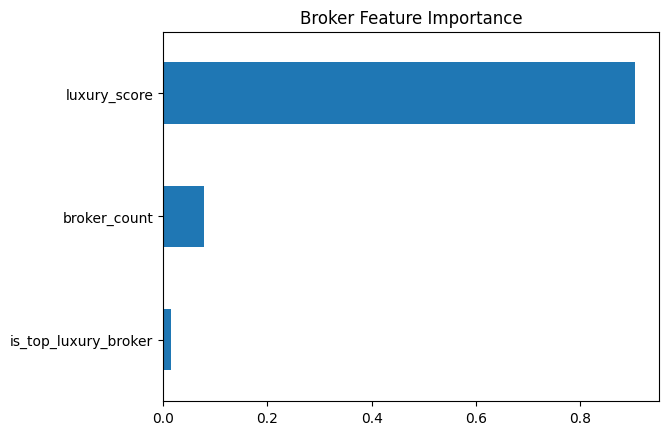

In [9]:
importances = pd.Series(model.feature_importances_, index=broker_features).sort_values()
importances.plot(kind='barh', title='Broker Feature Importance')

In [10]:
df[['luxury_score', 'price']].corr()

,luxury_score,price
luxury_score,1.00000,0.36752
price,0.36752,1.00000


In [11]:
df.brokertitle.value_counts().describe()

count    1035.000000
mean        4.427053
std        15.918532
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       435.000000
Name: count, dtype: float64

In [12]:
# In previous attemnt I write "High cardinality variable, it looks like it's not going to be helpfull"
# But now I think I am going to use brokers data in some form on modelling
# Probably wiil TARGET ENCODE broker luxury score on train data